---
title: Moments and distributions
---

In [120]:
from phasic import Graph, with_ipv
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set_palette('tab10')
from vscodenb import set_vscode_theme
set_vscode_theme()
np.random.seed(42)


Define a graph:

In [121]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append((new, state[i]*(state[j]-same)/(1+same)))
    return transitions

Build the graph:

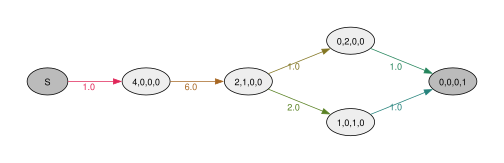

In [122]:
graph = Graph(coalescent)
graph.plot()

## Mean, variance, and higher moments

This phase-type distribution models the time until all lineages have coalesced. For convenience, we can get its expectation and variance like this:

In [123]:
graph.expectation()

1.4999999999999996

In [124]:
graph.variance()

1.1388888888888893

You can get any number of moments like this (here three):

In [125]:
graph.moments(3)

[1.4999999999999996, 3.388888888888888, 10.583333333333332]

In [126]:
#| echo: false
if 'pytest' in sys.modules: assert pytest.approx(graph.expectation()) == 1.5

In [127]:
#| echo: false
if 'pytest' in sys.modules: assert pytest.approx(graph.variance()) == 1.1388888

## Expected waiting time at states

In addition to the waiting time from the starting state, we can compute exact expected waiting times from each state:        

In [128]:
graph.expected_waiting_time()

[1.4999999999999996, 1.4999999999999996, 1.333333333333333, 1.0, 1.0, 0.0]

Or with the state vectors:

In [129]:
pd.DataFrame(graph.states()).assign(expectation=graph.expected_waiting_time())

,0,1,2,3,expectation
0,0,0,0,0,1.500000
1,4,0,0,0,1.500000
2,2,1,0,0,1.333333
3,0,2,0,0,1.000000
4,1,0,1,0,1.000000
5,0,0,0,1,0.000000


These expectations are used to compute higher moments. The MGF has the beautiful property that all moments are expectations with rewards derived from lower moment expectations at each state. Here is the first and second one again:

In [130]:
graph.expectation(), 2 * graph.expectation(graph.expected_waiting_time())

(1.4999999999999996, 3.388888888888888)

## Expected total time spent in states

Compute the exact expected total time spent in each state:

In [131]:
graph.expected_sojourn_time()

[0.0,
 0.16666666666666663,
 0.33333333333333326,
 0.3333333333333333,
 0.6666666666666666,
 0.0]

## CDF / PDF

We can get the CDF and PDF. The distribution methods reuse cached computations and recompute only if the graph changes. Compare the running times for the first and second call to the function:

In [132]:
time = np.arange(0, 4, 0.001)

In [133]:
%%time
cdf = graph.cdf(time)

CPU times: user 223 μs, sys: 54 μs, total: 277 μs
Wall time: 280 μs


In [134]:
%%time
cdf = graph.cdf(time)

CPU times: user 46 μs, sys: 4 μs, total: 50 μs
Wall time: 51.3 μs


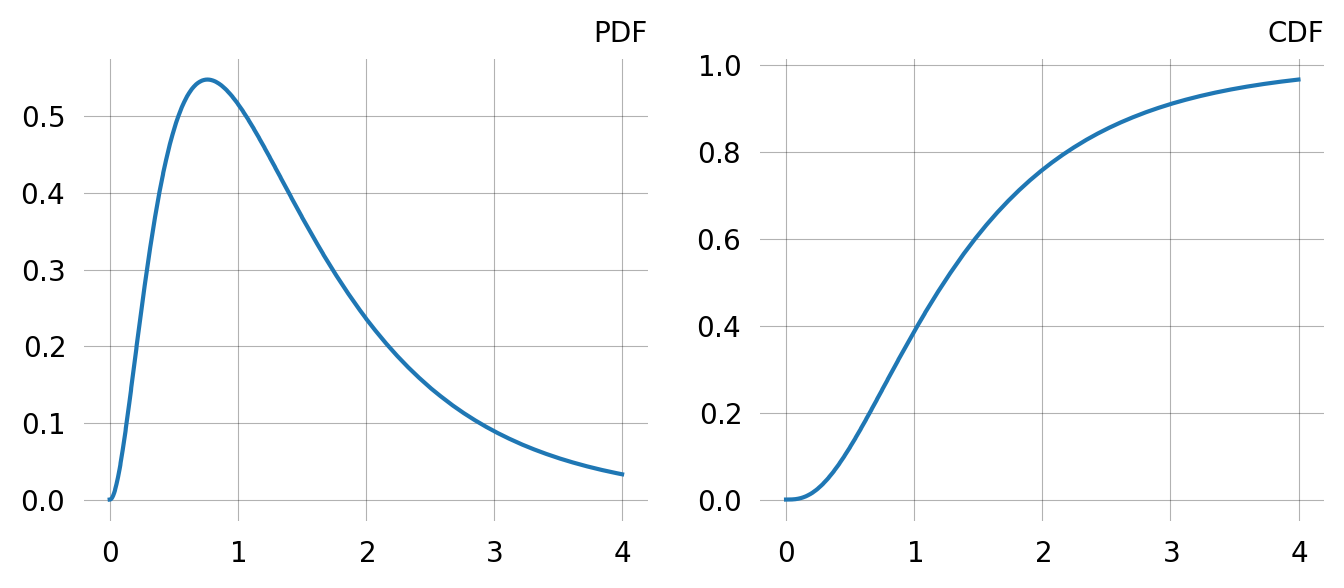

In [135]:
#| label: fig-pdf-cdf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(time, graph.pdf(time))
ax1.set_title("PDF")
ax2.plot(time, graph.cdf(time))
ax2.set_title("CDF") ;

## Rewards

We can add rewards which are based on the number of doubletons:

In [136]:
graph = Graph(coalescent)
reward_matrix = graph.states().T
doubletons = reward_matrix[1]
doubletons

array([0, 0, 1, 2, 0, 0], dtype=int32)

Adding these rewards, the phase-type distribution now represent the total doubleton branch length (total length of branches with two descendants). The expectation and variance are now:

In [137]:
graph.expectation(doubletons), graph.variance(doubletons)

(0.9999999999999999, 2.333333333333333)

Using rewards to the moment functions etc. is much faster than changing the graph. Here is the SFS (Site Frequency Spectrum) computed in this way. The 4'ton is included to illustrate that it is represented but has expectation zero since this it the absorbing TMRCA.

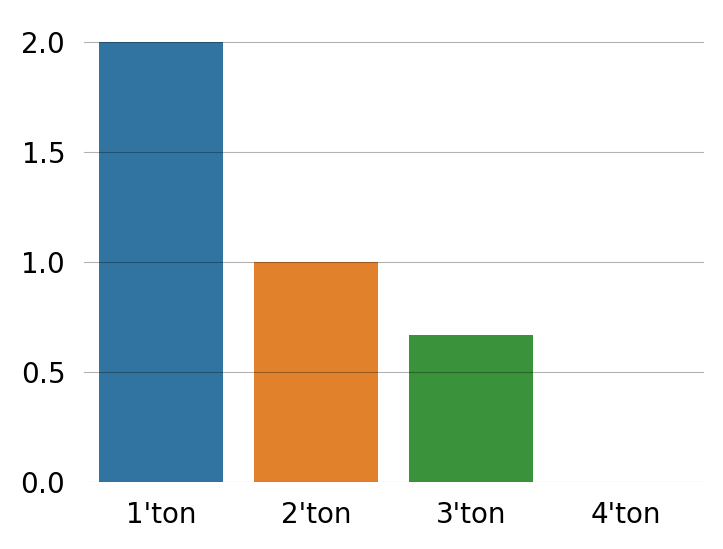

In [138]:
#| label: fig-sfs
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[0])]
sfs = [graph.expectation(r) for r in reward_matrix]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=sfs, hue=labels) ;

### Reward transforms

And here by doing each reward_transform:

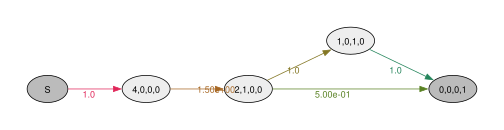

In [139]:
#| label: fig-singleton-rev-trans
singleton_graph = graph.reward_transform(reward_matrix[0])
singleton_graph.plot()

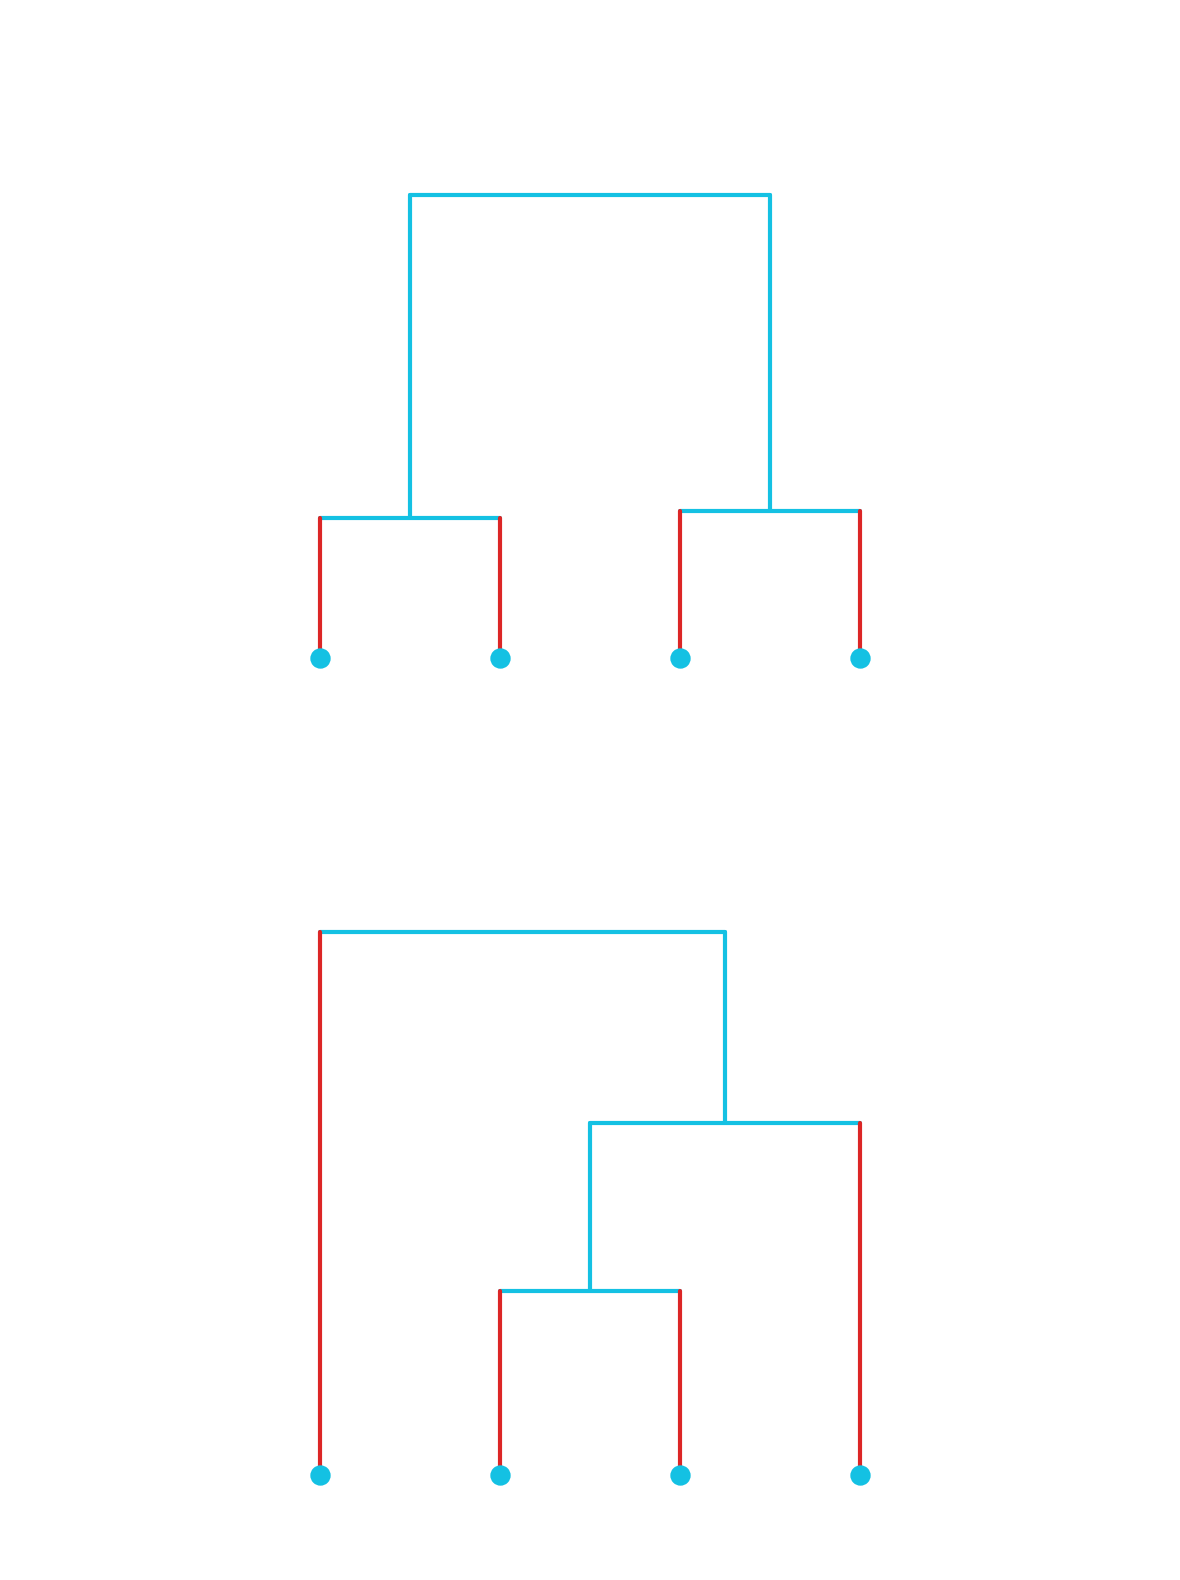

In [140]:
#| echo: false 
#| label: fig-singleton-branches
#| column: margin
#| fig-cap: "Singleton branch length"
from phasic.utils import tree_illustration
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
tree_illustration('TTTT', ton=1, ton_label=False, balanced=False, seed=1, ax=ax1);
tree_illustration('TTTT', ton=1, ton_label=False, balanced=False, seed=2, ax=ax2);
plt.tight_layout()

In [141]:
reward_matrix[1]

array([0, 0, 1, 2, 0, 0], dtype=int32)

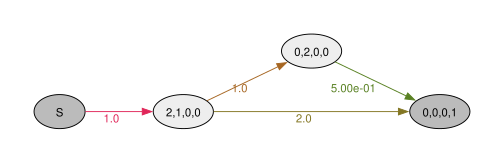

In [142]:
#| label: fig-doubleton-rev-trans
doubleton_graph = graph.reward_transform(reward_matrix[1])
doubleton_graph.plot()

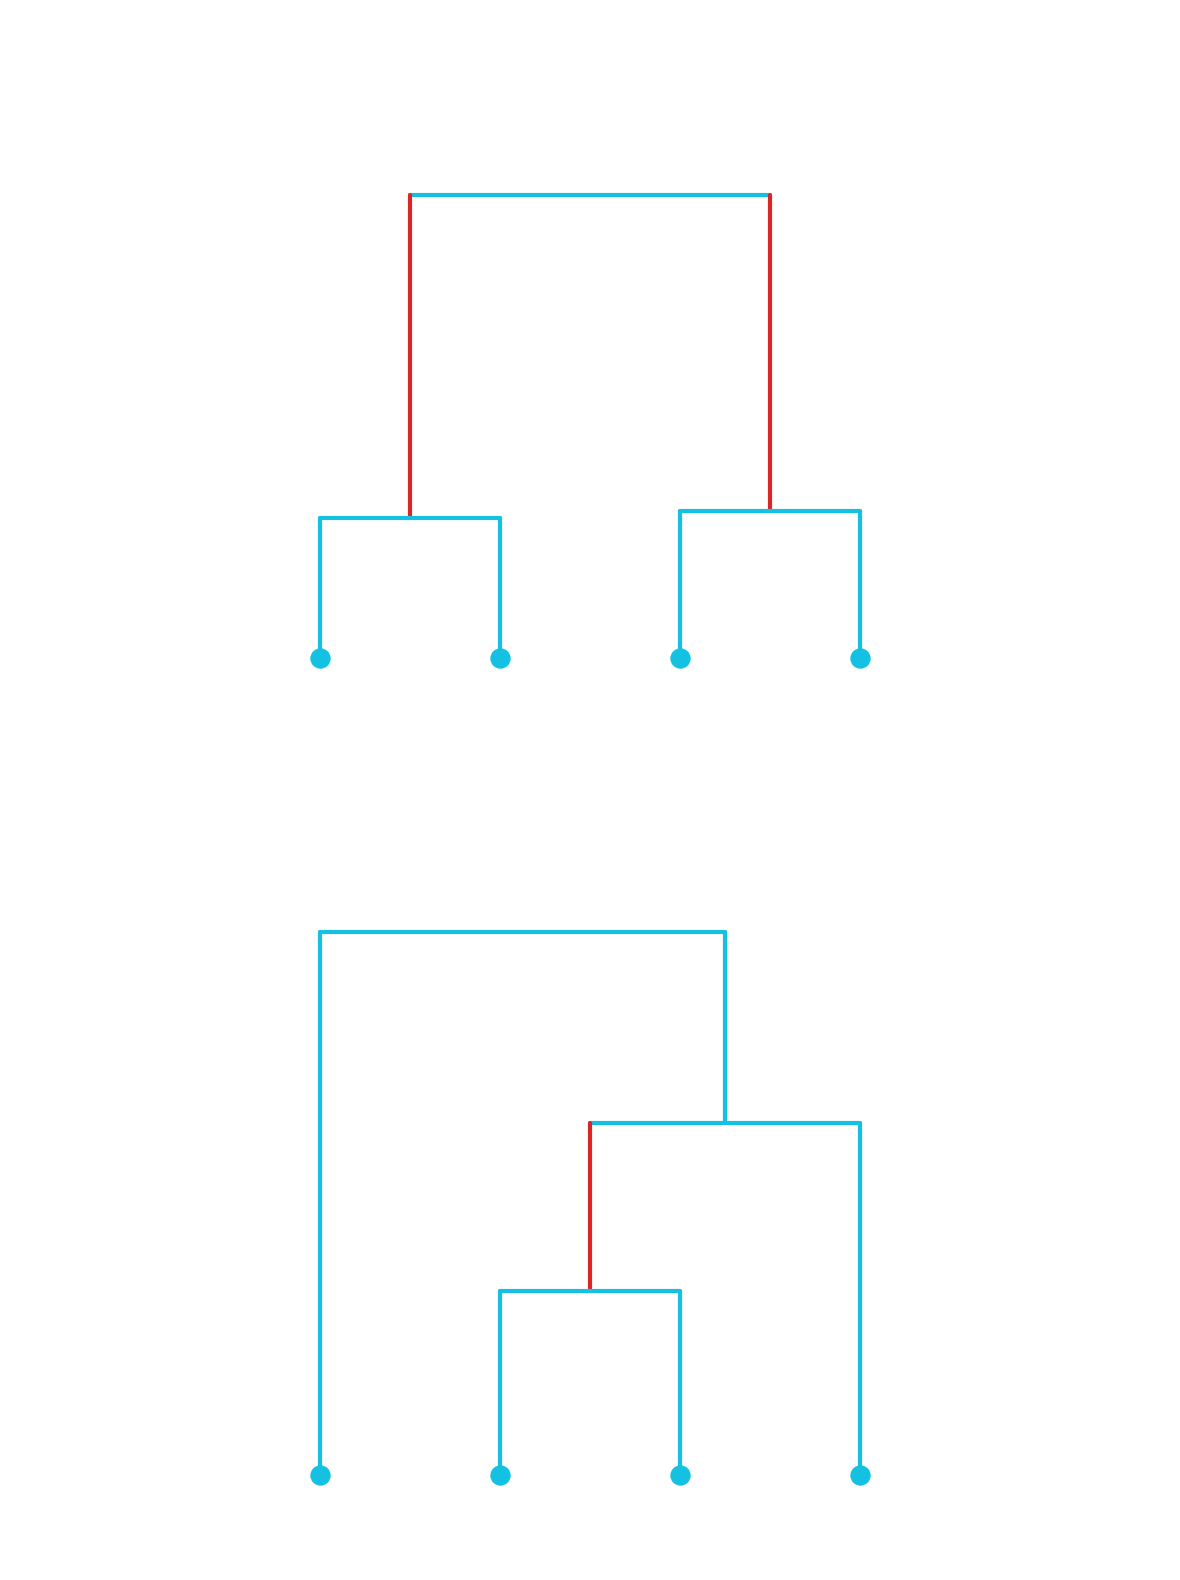

In [143]:
#| echo: false 
#| label: fig-doubleton-branches
#| column: margin
#| fig-cap: "Double branch length"
from phasic.utils import tree_illustration
# tree_illustration('TTTT', ton=2, ton_label=False, seed=4) ;
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))
tree_illustration('TTTT', ton=2, ton_label=False, balanced=False, seed=1, ax=ax1);
tree_illustration('TTTT', ton=2, ton_label=False, balanced=False, seed=2, ax=ax2);
plt.tight_layout()

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_3512/3613828379.py:2: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  tripleton_graph = graph.reward_transform(reward_matrix[2])


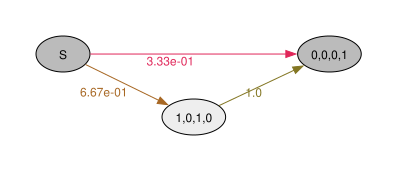

In [144]:
#| label: fig-tripleton-rev-trans
tripleton_graph = graph.reward_transform(reward_matrix[2])
tripleton_graph.plot()

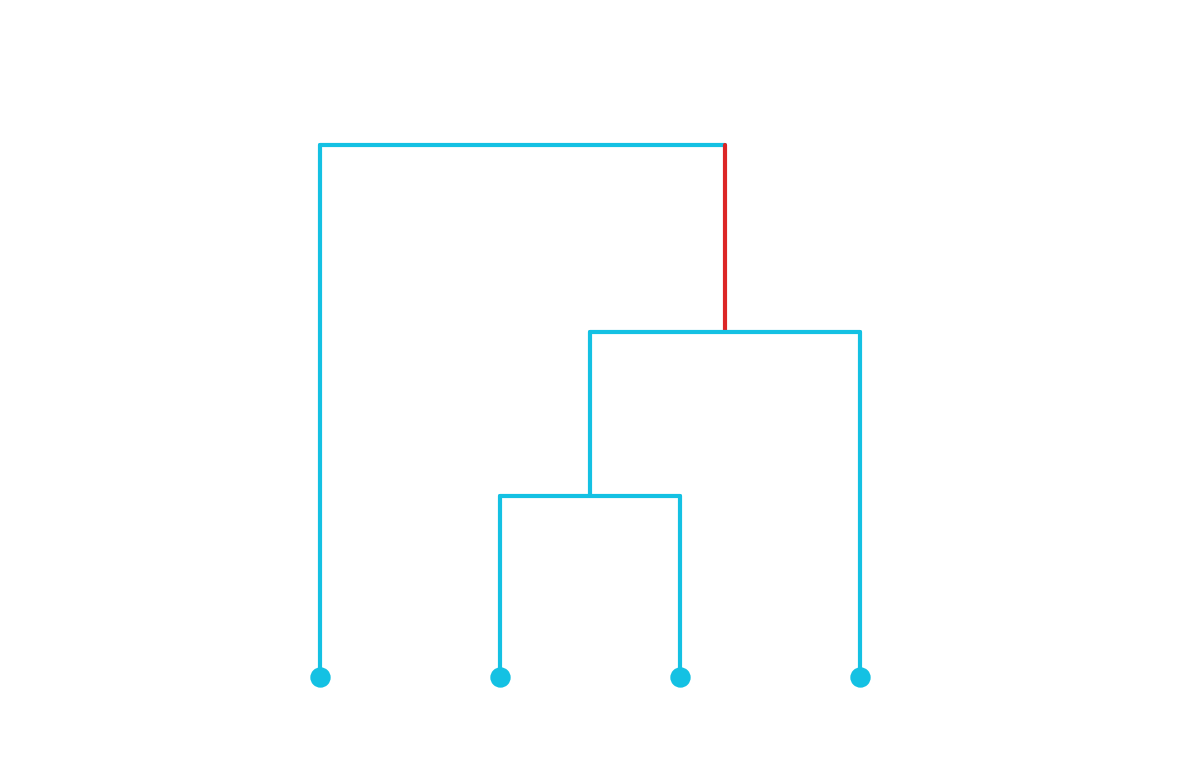

In [145]:
#| echo: false 
#| label: fig-tripleton-branches
#| column: margin
#| fig-cap: "Tripleton branch length"
from phasic.utils import tree_illustration
tree_illustration('TTTT', ton=3, ton_label=False, balanced=False, seed=2) ;

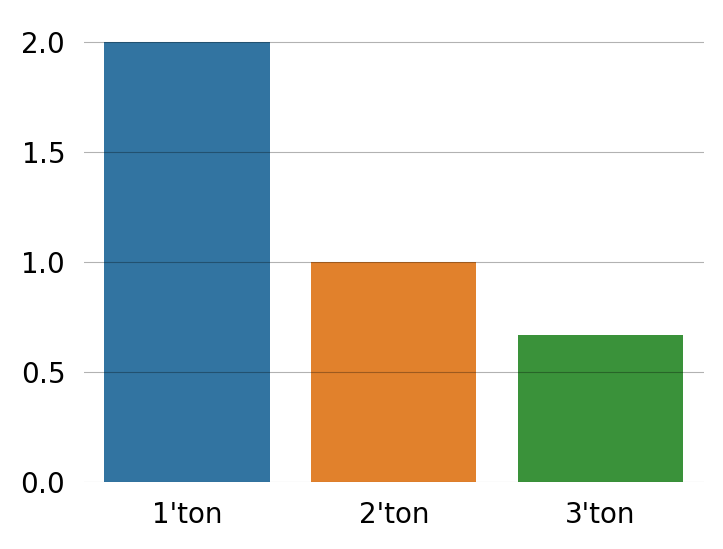

In [146]:
sfs = [
    singleton_graph.expectation(),
    doubleton_graph.expectation(),
    tripleton_graph.expectation(),
]
plt.figure(figsize=(4, 3))
sns.barplot(x=labels[:len(sfs)], y=sfs, hue=labels[:len(sfs)]) ;

Computing the (unrewarded) expectation on the reward-transforming graph produces the same result as passing the rewards to `expectation`, but is much slower:

In [147]:
graph = Graph(coalescent)
singleton_rewards = graph.states().T[0]

In [148]:
%%timeit
graph.expectation(singleton_rewards)

4.9 μs ± 282 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [149]:
%%timeit
graph.reward_transform(singleton_rewards).expectation()

39.9 μs ± 2.08 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


The real use of reward transformation is that it provides the full distribution of accumulated rewards. For example if we want the marginal distributions:

In [150]:
graph.states().T[:-1]

array([[0, 4, 2, 0, 1, 0],
       [0, 0, 1, 2, 0, 0],
       [0, 0, 0, 0, 1, 0]], dtype=int32)

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_3512/727287579.py:10: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  revt_graph = graph.reward_transform(rewards)


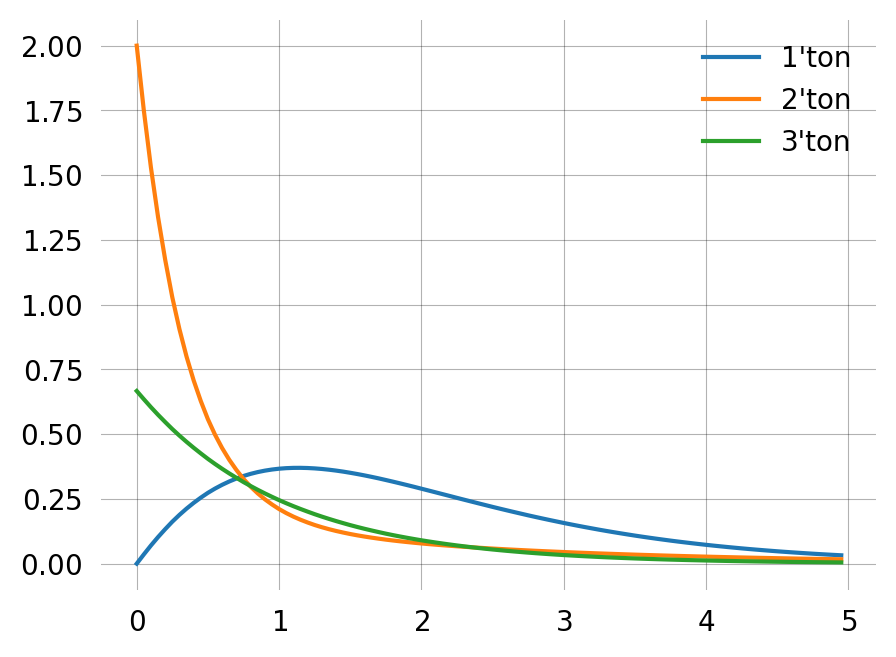

In [166]:
#| label: fig-sfs-marginal-pdfs
#| legend: "Marginal PDFs. Notice the how 3'ton branch lengths do not zum to one because it has a point mass at zero."
graph = Graph(coalescent)
times = np.arange(0, 5, 0.05)
reward_matrix = graph.states().T
reward_matrix = reward_matrix[:-1]
labels = [f"{i+1}'ton" for i in range(reward_matrix.shape[1])]

for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.pdf(times), label=labels[i])
plt.legend() ;

Marginal distributions can have a point mass at zero. In out coalescent example, there is a non-zero probability there is no 3'ton branch at all. The marginal PDF can only represent the continuous part, but the point mass is represented as the deficit when the PDF is integrated over rewards (I.e., the probability distribution does not sum to one). In the CDF, the point mass is clearly represented as the cumulative probability at zero reward: The 3'ton CDF does not begin at zero probability like the 1'ton and 2'ton.

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_3512/3566753439.py:8: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  revt_graph = graph.reward_transform(rewards)


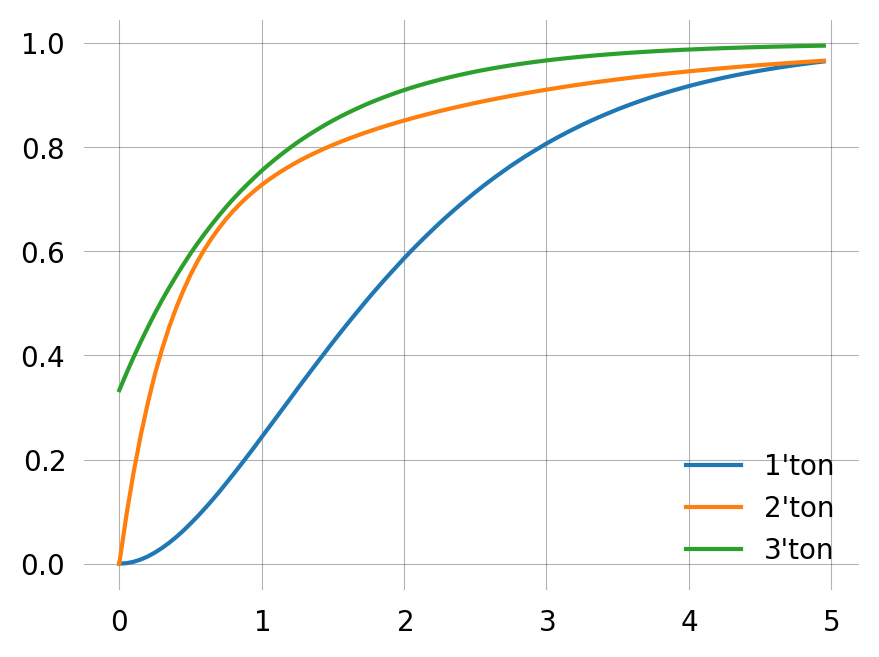

In [ ]:
#| label: fig-sfs-marginal-cdfs
#| legend: "Marginal CDFs. Notice the point mass at zero for 3'ton branch length."
for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    plt.plot(times, revt_graph.cdf(times), label=labels[i])
plt.legend() ;

In [156]:
times = np.arange(0, 20, 0.00001)
for i, rewards in enumerate(reward_matrix):
    revt_graph = graph.reward_transform(rewards)
    print(np.sum(revt_graph.pdf(times) * 0.00001))

0.9999999901057668
1.0019446704033461
0.6673209340391812


/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_3512/180978633.py:3: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  revt_graph = graph.reward_transform(rewards)


## Reward validation


phasic enforces two structural conditions on every reward vector before computing anything that depends on it: shape, and coverage. The checks run on the `rewards=` argument to `graph.reward_transform`, `graph.pdf`, `graph.sample`, and `Graph.svgd`. Shape mismatches are always errors — wrong-length rewards are bugs that would otherwise go through C++ as misaligned arrays. Coverage failures are *not* errors: they describe a legitimate (atom + continuous) mixture distribution, and most call paths just warn so the user knows the shape of their distribution.

Coverage checking can be disabled with `validate_rewards=False`. Don't disable it casually — the warning is informative and telling you something real about your model. Shape checks are always enforced regardless of this flag.

**Shape.** Rewards must be a 1-D array of length `n_vertices` (one reward per vertex) or a 2-D array of shape `(n_features, n_vertices)` for multivariate phase-type distributions where each feature has its own reward vector. The validator emits a clear error naming the expected and actual shape, and adds a transpose hint if the 2-D shape looks backwards (`(n_vertices, n_features)`):

```
ValueError: rewards: 2D rewards must have shape (n_features, n_vertices=N), got shape (N, F).
  Hint: you appear to have a (n_vertices=N, n_features=F) array. Transpose it: rewards = rewards.T.
```

Shape errors are never safe to ignore — they always indicate a bug in how you constructed the array.

In [ ]:
# Trigger the shape error: pass a vector that is too long.
import numpy as np
try:
    graph.reward_transform(np.ones(graph.vertices_length() + 1))
except ValueError as exc:
    print(exc)

**Coverage.** Every trajectory from a starting vertex to an absorbing vertex must visit at least one rewarded vertex *if you want the reward-transformed distribution to be strictly continuous*. If some trajectories skip every reward, those trajectories absorb in zero accumulated reward and the transformed distribution has a point mass at $r = 0$ with weight $1 - p(\theta)$, where $p(\theta) = P(\text{trajectory visits a rewarded vertex})$. The continuous density returned by `pdf(t)` covers the $r > 0$ tail and integrates to $p(\theta)$; the atomic mass equals `cdf(0)` on the reward-transformed graph and accounts for the remaining $1 - p(\theta)$. The full distribution is a proper mixture — no missing mass, no bias.

The validator does a BFS in the subgraph that excludes all rewarded vertices and reports the first witness path it finds from a start vertex to absorption:

```
UserWarning: rewards: some trajectories accumulate zero
reward. The reward-transformed distribution has a point
mass at r = 0 with weight 1 - P(visit a rewarded vertex);
the continuous density returned by `pdf(t)` covers only
r > 0. Read the atomic mass with `cdf(0)` on the
transformed graph. `Graph.svgd` combines both into a
zero-inflated likelihood automatically.
```

Three legitimate responses, depending on what you want to model:

1. **Atom is intentional / not a problem.** Do nothing. The distribution is a (atom + continuous) mixture; `Graph.svgd` handles it via zero-inflation, `graph.sample` produces a mixture of zeros and positive values, and you can read the atomic mass directly as `graph.reward_transform(r).cdf(0.0)`.
2. **You want strictly continuous on $r > 0$.** Modify the reward decomposition so every trajectory hits a rewarded vertex. Common patterns: use `graph.states().T` as the reward matrix, or merge a sparse reward with another so the combined vector covers all trajectories.
3. **You want the conditional density $f(r \mid r > 0)$.** Read the continuous part directly. It integrates to $p(\theta) < 1$; divide by $p(\theta) = 1 - \text{cdf}(0)$ to renormalise.

**Partial coverage in SVGD: zero-inflated likelihood.** When you call `Graph.svgd(observed_data, rewards=...)` and the validator detects partial coverage, SVGD silently switches to a zero-inflated likelihood:

$$\mathcal{L}(\theta) = \sum_i \log p(x_i \mid \theta) \, \mathbf{1}[x_i > 0] + n_{\text{zero}} \, \log(1 - p(\theta))$$

where $p(\theta) = P(\text{trajectory visits a rewarded vertex})$ and $n_{\text{zero}}$ is the count of observations with $r = 0$. The continuous-density term covers the $r > 0$ tail; the point-mass term covers the atom at $r = 0$ that comes from trajectories that skip every reward.

No warning is emitted — partial coverage is the expected shape for many multi-feature workflows (per-state branch-length decompositions, mutation-count features, anything where the tree decomposes into per-state contributions that most trajectories don't all hit). The list of zero-inflated features and the corresponding zero-counts is exposed on the SVGD object for inspection:

```python
svgd = graph.svgd(observed_data, rewards=...)
svgd.zero_inflated_features   # e.g. [2, 5]
svgd.n_zero_per_feature       # e.g. array([12, 34])
```

`svgd.summary()` also prints a line naming the affected features and their zero counts when the zero-inflated likelihood is active.

**Opting out: `validate_rewards=False`.** Every entry point that runs the validator accepts `validate_rewards=False` to disable the coverage check. Shape errors are always raised regardless of this flag — those are bugs, not modelling choices. Reasons to opt out of the coverage warning:

1. You are scripting a one-shot read on a known mixture distribution and don't need the warning every time.
2. You are reproducing a numerical result from a paper or older phasic version where the warning didn't exist.
3. You are intentionally modelling a sub-stochastic continuous part (rare; you almost always want zero-inflation instead).

Reasons NOT to opt out:

1. The warning is annoying. It's telling you something real about your distribution; learn the shape, then decide whether to silence per-call.
2. You want SVGD to use a simpler likelihood. The zero-inflated likelihood is correct; the warning just tells you it's active.

## State probability over time

### State probability

Alias for `stop_probability`. Computes the state probability, the probabilities of occupying each state at time t. 

In [32]:
graph = Graph(coalescent)
graph.state_probability(0.2)

[0.0,
 0.29978049956512576,
 0.4964527753776389,
 0.06299978987254216,
 0.12599957974508433,
 0.0]

We can use that to compute the expected number of lineages across time:

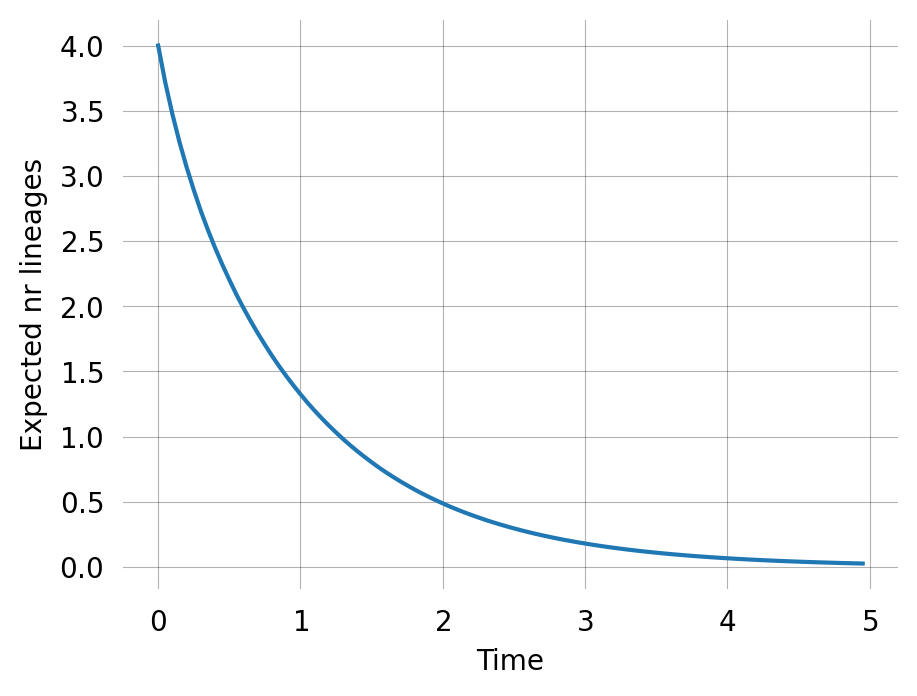

In [33]:
#| label: fig-tot-lineages-across-time
times = np.arange(0, 5, 0.05)
expected_lineages_left = [
    np.sum(graph.state_probability(i) 
           * np.sum(graph.states(), axis=1)) 
    for i in times
    ]

fig, ax = plt.subplots(1, 1)
ax.plot(times, expected_lineages_left)
ax.set_xlabel('Time')
ax.set_ylabel("Expected nr lineages") ;

We can also get the accumulated visiting time of a particular state. E.g. the total doubleton branchlength before time t=1.5:

The same way we can also compute the expected number of *each kind* of lineage across time:

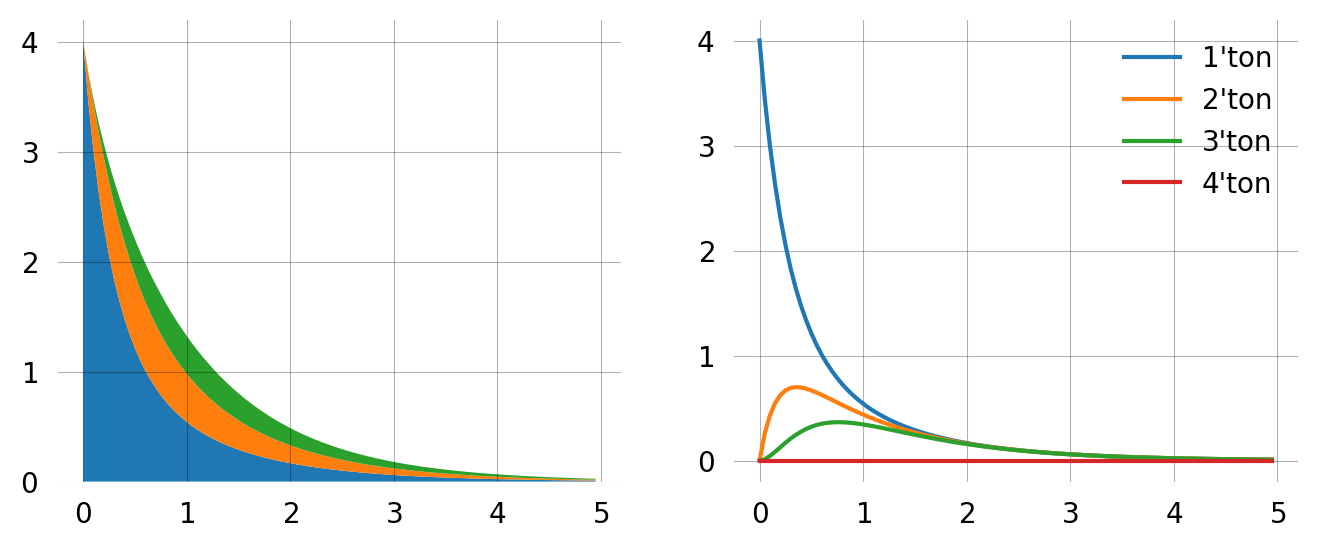

In [34]:
#| label: fig-ton-lineages-across-time
times = np.arange(0, 5, 0.05)
state_probs = np.array([graph.state_probability(i) * graph.states().T for i in times])
labels = [f"{i+1}'ton" for i in range(state_probs.shape[1])]
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T)
axes[1].plot(times, np.sum(state_probs, axis=2), label=labels)
# plt.subplot(121).stackplot(times, np.sum(state_probs, axis=2).T)
# plt.subplot(122).plot(times, np.sum(state_probs, axis=2), label=labels)
plt.legend() ;

### Accumulated time spent in states by time

Total time spent in each state up to time t:

In [35]:
graph.accumulated_occupancy(0.3)

[0.0,
 0.13955067135532132,
 0.11830247033054878,
 0.013473490250327203,
 0.026946980500654406,
 0.0]

You can plot the accumulated occupancies along to see how they converge to the expected sojourn times (dashed lines):

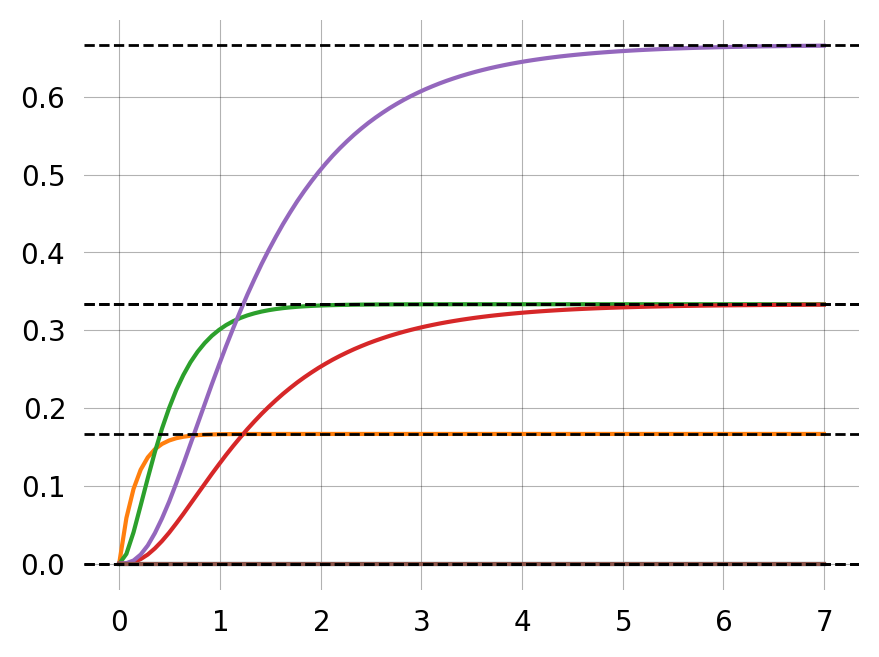

In [36]:
#| label: fig-accumulated-occupancies

times = np.linspace(0, 7, 100)
plt.plot(times, [graph.accumulated_occupancy(t) for t in times])
[plt.gca().axhline(t, ls='--', c='k', lw=1) for t in graph.expected_sojourn_time()] ;

# Random sampling

The library includes functions to do random sampling. These are useful to also validate the computations

In [37]:
graph = Graph(coalescent)
graph.sample(5)

array([0.49809798, 1.24383579, 2.78400146, 4.23380435, 2.30360114])

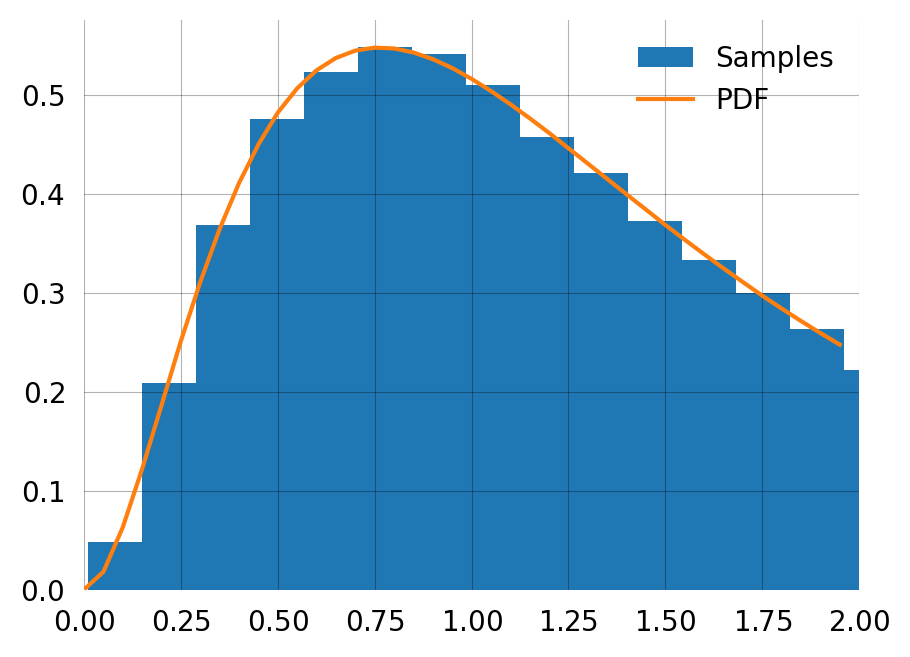

In [38]:
#| label: fig-tmrca-sampling-dist
#| fig-cap: "Sampling distribution."


fig, ax = plt.subplots()
samples = graph.sample(100000)

ax.hist(samples, bins=100, density=True, label='Samples')
x = np.arange(0, 2, 0.05)

ax.plot(x, [graph.pdf(t) for t in x], label='PDF')

ax.set_xlim(0, 2)
ax.legend();

You can produce the moments from sampling if needed. Here is the empirical first moment computed from samples compared ot the exact first moment:

In [39]:
np.sum(np.array(graph.sample(10000))).item()/10000, graph.moments(1)[0]

(1.5163422202929184, 1.4999999999999996)

Here is the empirical second moment computed from samples compared ot the exact second moment:

In [40]:
np.sum(np.array(graph.sample(10000))**2).item()/10000, graph.moments(2)[1]

(3.336049506798834, 3.388888888888888)